In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
cd ../../

/Users/ann/Documents/Quant finance study/WSQ/quant_project


In [3]:
from src.get_data.read_data import get_rets
from src.analysis.plotting import plot_corr

In [4]:
start_ts = '2023-01-01'
end_ts = '2025-12-31'

In [5]:
parquet_path = f"src/data/rets_{start_ts[:4]}_to_{end_ts[:4]}.parquet"

In [6]:
if os.path.exists(parquet_path):
    rets = pd.read_parquet(parquet_path)
else:
    rets = get_rets(freq='4h',start_ts = start_ts,end_ts=end_ts)

In [7]:
daily_rets = rets.iloc[5::6,]
daily_rets = daily_rets[:252]
daily_rets = daily_rets.dropna(axis=1)

In [8]:
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(daily_rets)

pca = PCA()
pca_result = pca.fit_transform(returns_scaled)

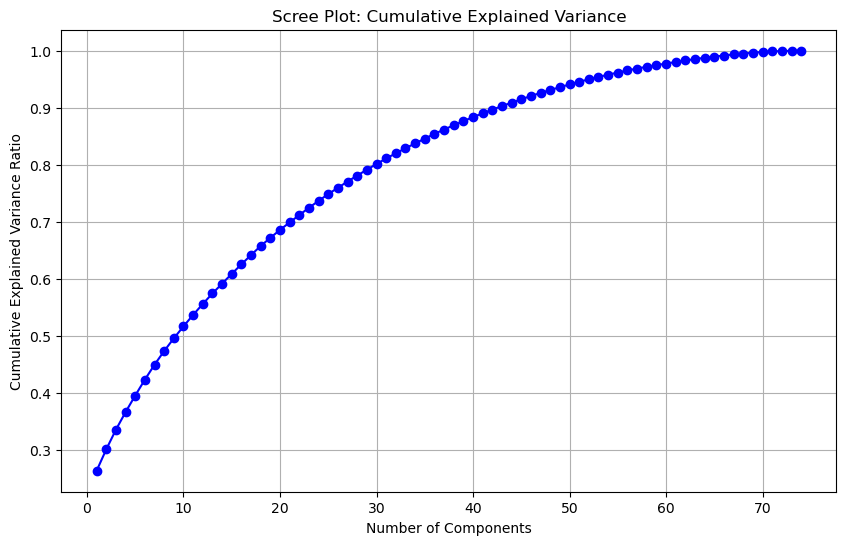

Explained variance ratio for first 3 components:
PC1: 0.264
PC2: 0.037
PC3: 0.034


In [9]:
pca_df = pd.DataFrame(
    pca_result,
    columns=[f'PC{i+1}' for i in range(len(daily_rets.columns))]
)

# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Scree Plot: Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Print explained variance for first 3 components
print("Explained variance ratio for first 3 components:")
for i, ratio in enumerate(pca.explained_variance_ratio_[:3]):
    print(f"PC{i+1}: {ratio:.3f}")

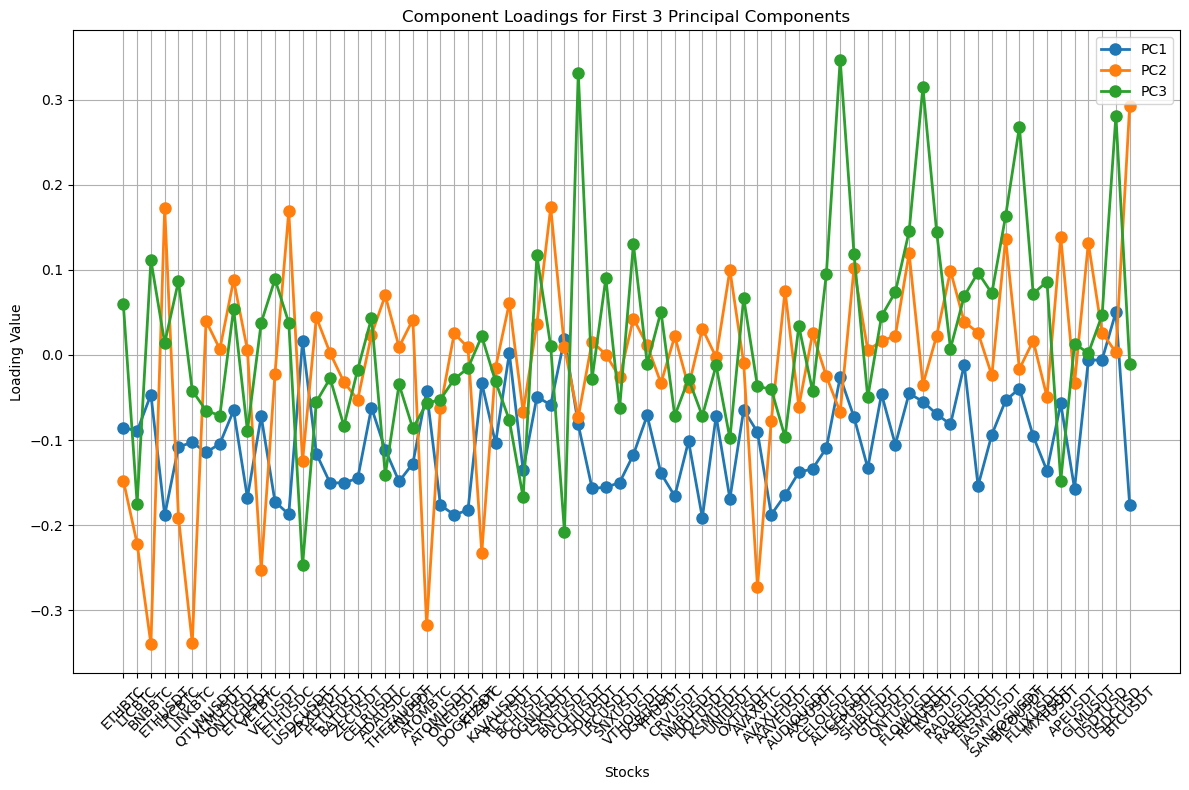

Top contributors to each principal component:

PC1:
DOTUSDT: 0.191
ETHUSDT: 0.188
ONEUSDT: 0.188

PC2:
BNBBTC: 0.340
LINKBTC: 0.338
ATOMBTC: 0.318

PC3:
ALICEUSDT: 0.347
COTIUSDT: 0.332
REQUSDT: 0.315


In [10]:
# Get component loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(daily_rets.columns))],
    index=daily_rets.columns
)

# Plot loadings for first 3 PCs on a single plot
plt.figure(figsize=(12, 8))
for i in range(3):
    plt.plot(loadings.index, loadings[f'PC{i+1}'], 
             marker='o', 
             linewidth=2, 
             markersize=8,
             label=f'PC{i+1}')

plt.title('Component Loadings for First 3 Principal Components')
plt.xlabel('Stocks')
plt.ylabel('Loading Value')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print top contributors for each PC
print("Top contributors to each principal component:")
for i in range(3):
    print(f"\nPC{i+1}:")
    top_contributors = loadings[f'PC{i+1}'].abs().sort_values(ascending=False).head(3)
    for stock, loading in top_contributors.items():
        print(f"{stock}: {loading:.3f}")

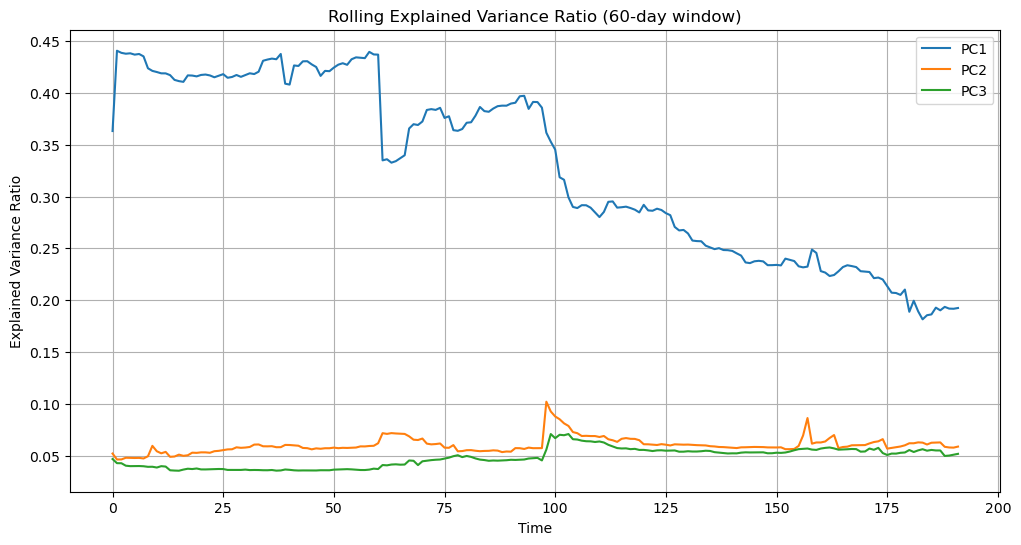

In [11]:
# Calculate rolling PCA (using 60-day windows)
window_size = 60
resid_list = []
rolling_pca = []

for i in range(window_size, len(daily_rets)):
    window_data = daily_rets.iloc[i-window_size:i]
    scaler = StandardScaler()
    window_scaled = scaler.fit_transform(window_data)

    pca = PCA(n_components=3)
    pca.fit(window_scaled)

    today = daily_rets.iloc[i:i+1]
    today_scaled = scaler.transform(today)

    scores_today = pca.transform(today_scaled)
    common_today = np.dot(scores_today, pca.components_)

    residual_today = today_scaled - common_today
    resid_list.append(residual_today)

    rolling_pca.append(pca.explained_variance_ratio_[:3])

resid_array = np.vstack(resid_list)


resid_df = pd.DataFrame(
    resid_array,
    index=daily_rets.index[window_size:],
    columns=daily_rets.columns
)

rolling_pca_df = pd.DataFrame(rolling_pca, columns=['PC1', 'PC2', 'PC3'])

# Plot rolling explained variance
plt.figure(figsize=(12, 6))
for col in rolling_pca_df.columns:
    plt.plot(rolling_pca_df.index, rolling_pca_df[col], label=col)
plt.xlabel('Time')
plt.ylabel('Explained Variance Ratio')
plt.title('Rolling Explained Variance Ratio (60-day window)')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
#plot_corr(resid_df.corr())

In [13]:
resid_df

,ETHBTC,LTCBTC,BNBBTC,ETHUSDT,LRCBTC,LINKBTC,QTUMUSDT,XLMUSDT,ONTUSDT,ETCUSDT,...,SANTOSUSDT,BICOUSDT,FLUXUSDT,IMXUSDT,TUSDT,APEUSDT,GLMUSDT,USDTUSD,USDCUSD,BTCUSDT
2023-03-03 00:00:00+00:00,2.928387,-1.272751,2.608285,0.679377,4.366466e-01,0.083634,-0.230194,1.500645,-2.379362,0.233208,...,-1.532443,-0.303453,2.150928,2.161808,2.063756,0.393178,-0.977538,1.915304,0.917828,-0.866740
2023-03-04 00:00:00+00:00,0.108369,-0.619088,0.073994,-0.010318,-2.001607e-01,-0.343093,0.522233,-0.733804,0.075031,-0.426350,...,-0.062821,-0.092482,0.325436,-0.128456,-0.817473,-0.053058,-2.551800,-0.058407,0.107330,-0.086105
2023-03-05 00:00:00+00:00,-0.835334,-0.241707,-0.435094,-0.487017,-9.524074e-02,0.146990,0.001553,-0.053520,-0.000911,0.078961,...,1.287929,-0.262429,-0.599898,0.034961,0.389139,-0.023585,-0.138519,-0.200694,-0.333082,-0.285024
2023-03-06 00:00:00+00:00,-0.045310,-0.637889,-0.580097,0.171257,2.215836e-01,-0.020068,-0.958680,0.625800,-0.708694,-0.442312,...,-0.510546,-0.372766,-0.096667,0.928954,-0.027020,0.756480,-0.217910,-0.272688,-0.107258,0.195379
2023-03-07 00:00:00+00:00,0.566515,-0.393309,-0.252079,0.194714,-3.475633e-01,0.992789,-0.427690,-0.112387,0.108274,-0.498820,...,-0.447497,-0.218487,-0.217934,0.656073,-0.338288,-0.144323,-0.325252,-0.483131,1.641764,-0.083558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-06 00:00:00+00:00,-0.599724,-0.500996,0.196843,-0.442149,-2.054472e-16,1.241602,0.060050,-0.863207,-1.699275,0.447051,...,0.409114,0.304556,-1.317331,-0.426846,-0.485968,-0.352360,0.018614,-0.555467,0.070640,-0.652004
2023-09-07 00:00:00+00:00,-0.622162,0.265466,-0.235342,0.690652,-5.857394e-16,1.452811,-0.875355,-0.922734,-0.920364,-1.662565,...,-0.963854,-0.444377,17.712934,-0.837748,0.627746,0.592048,-0.035554,-0.123779,0.085411,0.796839
2023-09-08 00:00:00+00:00,-0.695146,-0.314349,0.327070,0.070718,8.858150e-17,-0.627855,-0.291656,-0.216592,0.171369,0.101126,...,-0.042244,0.146365,-0.646705,-0.104632,-0.074928,0.693856,0.049839,-0.066839,0.087245,0.446162
2023-09-09 00:00:00+00:00,0.152007,0.238837,1.392305,-0.502186,-1.126379e-15,0.447654,-0.284915,0.052307,0.081738,0.649818,...,-0.444906,1.224214,-0.469805,-0.320819,-0.042168,0.060759,-0.416243,-0.485624,-0.076375,-0.646156


In [18]:
# construct signal based on resid?
Z = (resid_df - resid_df.rolling(window_size, min_periods=1).mean())/resid_df.rolling(window_size, min_periods=1).std()

In [19]:
Z

,ETHBTC,LTCBTC,BNBBTC,ETHUSDT,LRCBTC,LINKBTC,QTUMUSDT,XLMUSDT,ONTUSDT,ETCUSDT,...,SANTOSUSDT,BICOUSDT,FLUXUSDT,IMXUSDT,TUSDT,APEUSDT,GLMUSDT,USDTUSD,USDCUSD,BTCUSDT
2023-03-03 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-04 00:00:00+00:00,-0.707107,0.707107,-0.707107,-0.707107,-0.707107,-0.707107,0.707107,-0.707107,0.707107,-0.707107,...,0.707107,0.707107,-0.707107,-0.707107,-0.707107,-0.707107,-0.707107,-0.707107,-0.707107,0.707107
2023-03-05 00:00:00+00:00,-0.801294,0.899972,-0.726418,-0.933953,-0.416846,0.692102,-0.249933,-0.254327,0.549930,0.339193,...,0.985659,-0.384187,-0.875436,-0.512220,-0.107816,-0.517293,0.884860,-0.636456,-0.888513,0.314548
2023-03-06 00:00:00+00:00,-0.355073,0.128584,-0.670079,0.172059,0.448039,0.059990,-1.288738,0.304704,0.039291,-0.874485,...,-0.261673,-0.964322,-0.451886,0.171065,-0.353023,1.271402,0.673159,-0.589075,-0.465121,1.014283
2023-03-07 00:00:00+00:00,0.015429,0.608656,-0.404554,0.202586,-1.095612,1.654483,-0.383608,-0.420387,0.650529,-0.844777,...,-0.190834,0.300117,-0.491255,-0.081939,-0.536731,-0.867862,0.511033,-0.675328,1.461630,0.356519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-06 00:00:00+00:00,-0.756432,-0.841062,0.493095,-0.687314,-0.332742,1.264783,0.320257,-0.814819,-1.984418,1.217556,...,0.198467,0.631485,-1.974225,-0.372843,-0.851647,-0.449587,0.198216,-0.258221,-0.125501,-0.905226
2023-09-07 00:00:00+00:00,-0.758324,0.815174,-0.223549,1.797231,-0.333921,1.433656,-1.194687,-0.865569,-1.050589,-3.917227,...,-1.187153,-1.879773,7.281210,-0.680847,1.378099,0.948259,0.113058,-0.083107,-0.090803,1.718491
2023-09-08 00:00:00+00:00,-0.832002,-0.481205,0.696512,0.443827,-0.303771,-0.723980,-0.238213,-0.109618,0.193847,0.283035,...,-0.240866,0.109697,-0.421782,-0.119330,-0.023525,1.064936,0.254805,-0.056756,-0.079892,1.075248
2023-09-09 00:00:00+00:00,0.235271,0.729505,2.346429,-0.838482,-0.314640,0.399377,-0.233524,0.160600,0.100774,1.528295,...,-0.664735,3.366415,-0.342027,-0.294265,0.017111,0.106999,-0.490696,-0.249959,-0.853560,-0.889529


In [15]:
df = {}
df["SR"] = daily_rets.mean()/daily_rets.std()*np.sqrt(252)
df["IR"] = resid_df.mean()/resid_df.std()*np.sqrt(252)
df = pd.DataFrame(df)

In [16]:
df.sort_values(by=["IR"], ascending=False)

,SR,IR
RADUSDT,1.405199,1.436428
ENJUSDT,1.662611,1.361757
BNTUSDT,1.088512,1.207589
AAVEUSDT,0.736380,1.115077
RLCUSDT,0.956698,0.974641
...,...,...
ZECUSDT,0.342943,-1.347510
VETUSDT,-0.509372,-1.404448
FETUSDT,0.149406,-1.449177
BNBBTC,1.472015,-1.481505
